# 03a. Surface normal and curvature features

This notebook moves beyond distance-only clustering by computing local PCA normals and curvature on the exterior-only Synthetic_Rockpile scan.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.segmentation.surface_features import estimate_normals_curvature

SCAN_PATH = PROJECT_ROOT / 'data' / 'scanned_pointclouds' / 'synthetic_rockpile_exterior_only_scan.npz'
FEATURE_PATH = PROJECT_ROOT / 'data' / 'scanned_pointclouds' / 'synthetic_rockpile_exterior_surface_features.npz'
FIG_PATH = PROJECT_ROOT / 'outputs' / 'figures' / 'surface_normal_curvature_features.png'
FEATURE_PATH.parent.mkdir(parents=True, exist_ok=True)
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)

C:\Users\creep\code\python\synthetic-to-real-3d-rock-fragmentation


In [2]:
scan = np.load(SCAN_PATH)
points = scan['points_xyz'].astype(np.float32)
label_key = 'instance_labels' if 'instance_labels' in scan.files else 'fragment_ids'
true_labels = scan[label_key].astype(np.int32)
print('label key:', label_key)
print(points.shape, true_labels.min(), true_labels.max(), len(np.unique(true_labels)))

label key: fragment_ids
(68516, 3) 0 499 500


In [3]:
normals, curvature = estimate_normals_curvature(points, k_neighbors=30)
np.savez_compressed(
    FEATURE_PATH,
    points_xyz=points,
    instance_labels=true_labels,
    normals=normals,
    curvature=curvature,
    k_neighbors=np.array([30], dtype=np.int32),
)
print('saved:', FEATURE_PATH)
print('curvature range:', float(curvature.min()), float(curvature.max()), 'median:', float(np.median(curvature)))

saved: C:\Users\creep\code\python\synthetic-to-real-3d-rock-fragmentation\data\scanned_pointclouds\synthetic_rockpile_exterior_surface_features.npz
curvature range: 0.00037375566898845136 0.31328269839286804 median: 0.14403322339057922


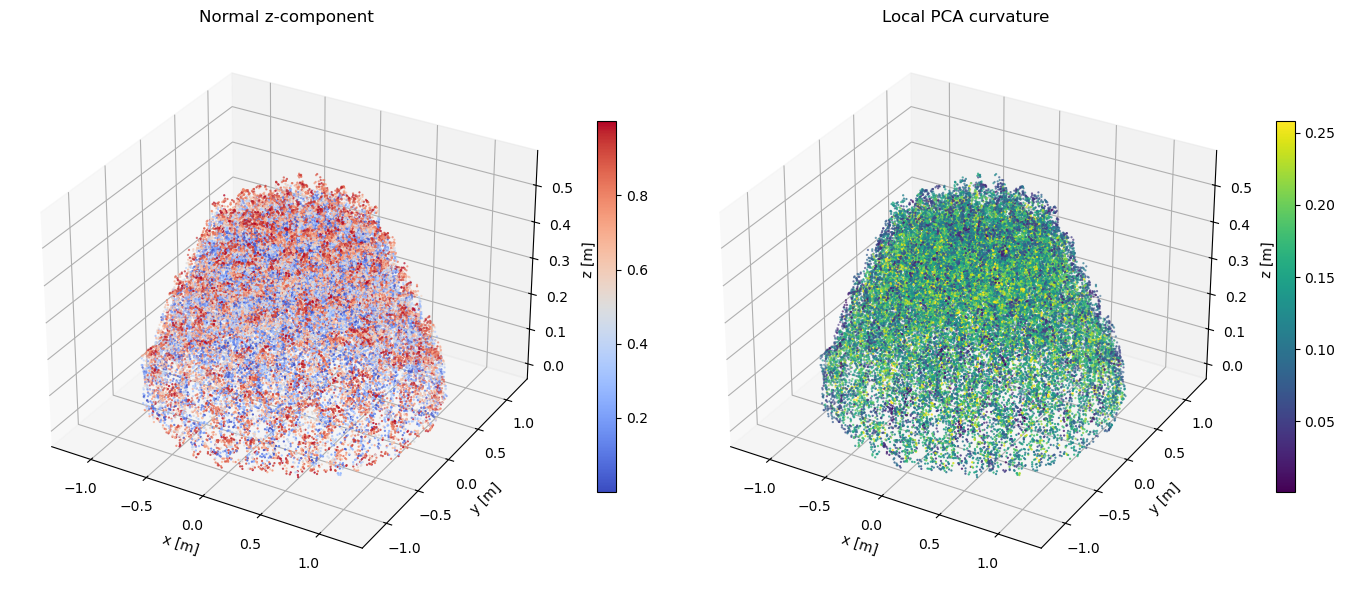

In [4]:
rng = np.random.default_rng(7)
idx = rng.choice(len(points), size=min(45000, len(points)), replace=False)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
p1 = ax1.scatter(points[idx,0], points[idx,1], points[idx,2], c=normals[idx,2], s=0.4, cmap='coolwarm')
ax1.set_title('Normal z-component')
ax1.set_xlabel('x [m]'); ax1.set_ylabel('y [m]'); ax1.set_zlabel('z [m]')
fig.colorbar(p1, ax=ax1, shrink=0.65)

ax2 = fig.add_subplot(122, projection='3d')
p2 = ax2.scatter(points[idx,0], points[idx,1], points[idx,2], c=np.clip(curvature[idx], 0, np.percentile(curvature, 98)), s=0.4, cmap='viridis')
ax2.set_title('Local PCA curvature')
ax2.set_xlabel('x [m]'); ax2.set_ylabel('y [m]'); ax2.set_zlabel('z [m]')
fig.colorbar(p2, ax=ax2, shrink=0.65)
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=180)
plt.show()